In [ ]:
import pickle
from pathlib import Path
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
import FFT_func
import random
import pickle
import gzip
from pathlib import Path
import sympy as sp
import plot_psi
from sympy import symbols, exp, Add, Mul, collect, expand
import os
from scipy.linalg import svd, eigh

# (n, N, N, N)->(N**3, n)
def grid_to_vec(y_grid):
    return y_grid.reshape(y_grid.shape[0], -1).T

# (N**3, n)->(n, N, N, N)
def vec_to_grid(y_grid, Nx, Ny, Nz):
    return y_grid.T.reshape(y_grid.shape[-1], Nx, Ny, Nz)

def svd_H(filtered_psi_matrix):
    C_f_grid = filtered_psi_matrix.copy()
    C_f = grid_to_vec(C_f_grid)
    C_f = C_f / np.linalg.norm(C_f, axis=0)
    inf_columns = np.any(np.isinf(C_f), axis=0)
    C_f = C_f[:, ~inf_columns]

    print("Performing QR decomposition...")
    Q_qr, R_qr = np.linalg.qr(C_f, mode='reduced')
    print(f"Q_qr dimensions: {Q_qr.shape}")
    print(f"R_qr dimensions: {R_qr.shape}")
    print("QR decomposition complete.")

    print("Performing SVD on R_qr...")
    U1_svd, Sigma_svd, V_svd_T = np.linalg.svd(R_qr, full_matrices=False)
    V_svd = V_svd_T.T
    print("SVD on R_qr complete.")

    print("Calculating U = Q_qr @ U1_svd...")
    U = Q_qr @ U1_svd
    print(f"Final U dimensions: {U.shape}")
    print(f"Sigma dimensions: {Sigma_svd.shape}")
    print(f"V_svd dimensions: {V_svd.shape}")

    rank_threshold = 1e-3
    r = np.sum(Sigma_svd > rank_threshold)
    print(f"Selected rank (r): {r}")

    Ur = U[:, :r]
    print(f"U_r dimensions: {Ur.shape}")

    Ur_grid = vec_to_grid(Ur, Nx, Ny, Nz)
    H_Ur_grid = np.zeros_like(Ur_grid, dtype='complex128')
    for i in range(H_Ur_grid.shape[0]):
        H_Ur_grid[i, :, :, :] = FFT_func.scaled_fft_eval_H_psi(Ur_grid[i, :, :, :], x_grid, V_on_grid)

    H_Ur = grid_to_vec(H_Ur_grid)
    H_tilde = Ur.T.conj() @ H_Ur
    energies_filtered, _ = eigh(H_tilde)
    energies_filtered = np.sort(energies_filtered)
    energies_filtered = energies_filtered[:200]
    return energies_filtered, Ur

def load_expr_srepr(path):
    """从 .srepr 或 .sym.gz 文件加载表达式"""
    if str(path).endswith(".gz"):
        with gzip.open(path, 'rt', encoding='utf8') as f:
            s = f.read()
    else:
        with open(path, 'r', encoding='utf8') as f:
            s = f.read()
    data = sp.sympify(s, evaluate=False)
    return data

def load_H_powers(folder, n_max, file_type='sym.gz'):
    folder = Path(folder)
    results = {}
    
    if file_type == 'pkl':
        pattern = "H_scaled_power_*.pkl"
    elif file_type == 'sym.gz':
        pattern = "H_scaled_power_*.sym.gz"
    else:
        raise ValueError(f"Unsupported file_type: {file_type}. Use 'pkl' or 'sym.gz'")
    
    for f in sorted(folder.glob(pattern)):
        n = int(f.stem.split('_')[-1] if file_type == 'pkl' 
                else f.name.split('_')[-1].split('.')[0])
        
        if file_type == 'pkl':
            with open(f, 'rb') as fh:
                data = pickle.load(fh)
        elif file_type == 'sym.gz':
            data = load_expr_srepr(f)
        
        results[n] = data
        if n == n_max:
            break
    
    return results

def chebyshev_coeffs_transformed(n, a=1.0, b=0.0):
    x = sp.Symbol('x')
    Tn = sp.chebyshevt(n, x)
    # 将 x 替换为 a*x + b
    Tn_transformed = Tn.subs(x, a*x + b)
    # 展开并提取系数
    Tn_expanded = sp.expand(Tn_transformed)
    poly = sp.Poly(Tn_expanded, x)
    coeffs = [poly.coeff_monomial(x**i) for i in range(n+1)]
    return coeffs

def apply_f_of_H_on_psi(folder, f_coeffs, n_max):
    results = load_H_powers(folder, n_max)
    N = len(f_coeffs) - 1
    x, y, z, kx, ky, kz, b = sp.symbols('x y z kx ky kz b')
    theta = kx*x + ky*y + kz*z + b

    # 初始化总和
    Ps_total = 0
    Pc_total = 0
    for n, c in enumerate(f_coeffs[1:]):  # 从 1 开始
        print('n',n)
        Ps_total += c * results[n+1]['Ps']
        Pc_total += c * results[n+1]['Pc']


    # 返回最终的符号表达式
    psi_fH = (Ps_total * sp.sin(theta) + Pc_total * sp.cos(theta)) + f_coeffs[0] * sp.sin(theta)
    print('psi_fH', psi_fH)
    return psi_fH

#folder = "H_symbolic_basis_expression_gaussian_AsIn"
#folder = "H_symbolic_basis_expression_gaussian"
folder = "H_scaled_powers_new_basis"

In [ ]:
import parse_file
x_grid, X, Y, Z, V_ref = parse_file.get_grid_and_V('grid-pot_cut_5p0.dat')

In [69]:
import os
import pickle
import numpy as np
import sympy as sp
import extract_grid
import importlib
import glob
import re
from collections import defaultdict

importlib.reload(extract_grid)

# 设置文件夹路径
folder_V_partition = r'C:\FD\test_cubic_space_partition_rcut=5.0_whole'
V_partition_files = glob.glob(os.path.join(folder_V_partition, '*.pkl'))
print(f"Found {len(V_partition_files)} pkl files")

# 定义符号变量
x, y, z, kx, ky, kz, b, a0, b0 = sp.symbols('x y z kx ky kz b a0 b0')

# 存储所有势能表达式和相关信息
V_expr_dict = {}  # {index: {'center': (cx, cy, cz), 'expr': expr, 'V_np': func, 'file_name': name}}


def load_V_expr_dict(V_partition_files, V_ref):
    import time
    total_time = 0
    
    # ===== 新增：加载全局格点数据并创建索引映射 =====
    grid_data = extract_grid.load_grid_data_once()
    n_total_points = len(grid_data)
    
    # 创建全局势能数组，初始化为0
    V_reconstructed_global = np.zeros(n_total_points)
    
    # 创建坐标到索引的映射（用于快速查找）
    # 使用字典，key为(x,y,z)的元组，value为在grid_data中的索引
    coord_to_index = {}
    for i in range(n_total_points):
        coord_key = tuple(grid_data[i, :3])  # (x, y, z)
        coord_to_index[coord_key] = i
    
    print(f"Initialized global V array with {n_total_points} points")
    # ===== 新增部分结束 =====
    
    for idx, file_path in enumerate(sorted(V_partition_files)):
        file_name = os.path.basename(file_path)
        
        # 解析中心坐标
        center = extract_grid.parse_center_from_filename(file_name)
        if center is None:
            print(f"Warning: Cannot parse center from {file_name}, skipping...")
            continue
        try:
            # 加载pkl文件
            with open(file_path, 'rb') as f:
                data = pickle.load(f)
            
            V_expr = data['expr']
            V_np = sp.lambdify((x, y, z), V_expr, 'numpy')
            
            # 存储表达式和相关信息
            V_expr_dict[idx] = {
                'center': center,
                'expr': V_expr,
                'V_np': V_np,
                'file_name': file_name
            }
            
            # 提取格点
            points_block = extract_grid.extract_grid(l0=4.0, file_name=file_name)
            error_results = []
            if len(points_block) == 0:
                print(f"Warning: No grid points found for {file_name}")
                error_results.append({
                    'index': idx,
                    'center': center,
                    'file_name': file_name,
                    'n_points': 0,
                    'err_max': np.nan,
                    'rel_err_max': np.nan,
                    'status': 'no_points'
                })
                continue
            
            # 计算重构的势能
            t1 = time.time()
            V_reconstructed_block = V_np(points_block[:,0],
                                        points_block[:,1],
                                        points_block[:,2])
            t2 = time.time()
            total_time += t2-t1
            
            # ===== 新增：将block势能值填入全局数组 =====
            # 找到points_block中每个点在全局数组中的索引
            global_indices = []
            for point in points_block:
                coord_key = tuple(point)
                if coord_key in coord_to_index:
                    global_indices.append(coord_to_index[coord_key])
                else:
                    # 如果坐标不完全匹配，尝试四舍五入（处理浮点精度问题）
                    coord_key_rounded = tuple(np.round(point, decimals=6))
                    if coord_key_rounded in coord_to_index:
                        global_indices.append(coord_to_index[coord_key_rounded])
                    else:
                        print(f"Warning: Point {point} not found in global grid")
            
            # 将计算得到的势能值填入全局数组
            if len(global_indices) == len(V_reconstructed_block):
                V_reconstructed_global[global_indices] = V_reconstructed_block
            else:
                print(f"Warning: Index mismatch for {file_name}")
            # ===== 新增部分结束 =====
            
            # 从原始文件提取势能（假设V_file, X, Y, Z已经定义）
            V_ref_block = extract_grid.extract_psi_fastest(V_ref, points_block, X, Y, Z, 64)
            
            # 计算误差
            err_max = np.max(np.abs(V_reconstructed_block - V_ref_block))
            
            # 计算相对误差（避免除零）
            denominator = np.abs(V_ref_block)
            mask = denominator > 1e-12  # 避免除以很小的数
            if np.any(mask):
                rel_err_max = np.max(np.abs(V_reconstructed_block[mask] - V_ref_block[mask]) / denominator[mask])
            else:
                rel_err_max = np.nan
            
            # 存储误差结果
            error_results.append({
                'index': idx,
                'center': center,
                'file_name': file_name,
                'n_points': len(points_block),
                'err_max': err_max,
                'rel_err_max': rel_err_max,
                'status': 'success'
            })
            
            print(f"[{idx}] Center: {center}, Points: {len(points_block)}, "
                f"Err: {err_max:.2e}, Rel_Err: {rel_err_max:.2e}")
            
        except Exception as e:
            print(f"Error processing {file_name}: {str(e)}")
            error_results.append({
                'index': idx,
                'center': center,
                'file_name': file_name,
                'n_points': 0,
                'err_max': np.nan,
                'rel_err_max': np.nan,
                'status': f'error: {str(e)}'
            })
    
    print("\n" + "="*80)
    print(f"Total files processed: {len(V_expr_dict)}")
    print(f"Total error records: {len(error_results)}")
    
    # ===== 新增：检查全局重构结果 =====
    n_filled = np.count_nonzero(V_reconstructed_global)
    print(f"Global reconstruction: {n_filled}/{n_total_points} points filled ({100*n_filled/n_total_points:.1f}%)")
    # ===== 新增部分结束 =====
    
    successful_results = [r for r in error_results if r['status'] == 'success']
    if successful_results:
        max_errors = [r['err_max'] for r in successful_results]
        rel_errors = [r['rel_err_max'] for r in successful_results if not np.isnan(r['rel_err_max'])]
        
        print(f"\nError Statistics:")
        print(f"  Max absolute error: {np.max(max_errors):.2e}")
        print(f"  Min absolute error: {np.min(max_errors):.2e}")
        print(f"  Mean absolute error: {np.mean(max_errors):.2e}")
        if rel_errors:
            print(f"  Max relative error: {np.max(rel_errors):.2e}")
            print(f"  Mean relative error: {np.mean(rel_errors):.2e}")
    
    # ===== 修改返回值，同时返回全局数组 =====
    return V_expr_dict, V_reconstructed_global, grid_data
    # ===== 修改结束 =====

# ===== 修改调用方式 =====
V_expr_dict, V_reconstructed_global, grid_data = load_V_expr_dict(V_partition_files, V_ref)
# ===== 修改结束 =====

print(V_expr_dict[0])

Found 32 pkl files
Loaded grid data: 262144 points
Initialized global V array with 262144 points
index 32 32 32
[0] Center: (2.0, 2.0, 2.0), Points: 343, Err: 1.08e+00, Rel_Err: 1.00e+00
index 32 32 39
[1] Center: (2.0, 2.0, 6.0), Points: 294, Err: 1.04e+00, Rel_Err: 1.00e+00
index 32 32 26
[2] Center: (2.0, 2.0, -2.0), Points: 343, Err: 4.72e-01, Rel_Err: 1.00e+00
index 32 32 20
[3] Center: (2.0, 2.0, -6.0), Points: 294, Err: 1.07e+00, Rel_Err: 1.00e+00
index 32 39 32
[4] Center: (2.0, 6.0, 2.0), Points: 294, Err: 1.04e+00, Rel_Err: 1.00e+00
index 32 39 26
[5] Center: (2.0, 6.0, -2.0), Points: 294, Err: 1.07e+00, Rel_Err: 1.00e+00
index 32 26 32
[6] Center: (2.0, -2.0, 2.0), Points: 343, Err: 4.72e-01, Rel_Err: 1.00e+00
index 32 26 39
[7] Center: (2.0, -2.0, 6.0), Points: 294, Err: 1.07e+00, Rel_Err: 1.00e+00
index 32 26 26
[8] Center: (2.0, -2.0, -2.0), Points: 343, Err: 1.08e+00, Rel_Err: 1.00e+00
index 32 26 20
[9] Center: (2.0, -2.0, -6.0), Points: 294, Err: 1.04e+00, Rel_Err: 1.0

In [72]:
import numpy as np

def save_potential_data(points_global, V_reconstructed_global, filename='potential_data.txt'):
    """
    保存电势数据到txt文件
    
    Parameters:
    -----------
    points_global : numpy array, shape (N, 3)
        xyz坐标，单位是Bohr
    V_reconstructed_global : numpy array, shape (N, 1) or (N,)
        计算的电势值，单位是Hartree
    filename : str
        输出文件名
    """
    # 确保V_reconstructed_global是1维的
    if V_reconstructed_global.ndim == 2:
        V_reconstructed_global = V_reconstructed_global.flatten()
    
    # 打开文件写入
    with open(filename, 'w') as f:
        # 写入表头
        f.write('# x(Bohr) y(Bohr) z(Bohr) V_calc(Ha)\n')
        
        # 写入数据
        for i in range(len(points_global)):
            x, y, z = points_global[i]
            V = V_reconstructed_global[i]
            # 使用科学计数法格式，保持与你的示例一致
            f.write(f'{x:19.8e} {y:19.8e} {z:19.8e} {V:19.8e}\n')
    
    print(f'数据已保存到 {filename}')

# 使用示例
save_potential_data(points_global, V_reconstructed_global, 'test_grid-pot_cubic_reconstructed_cut_5.dat')

数据已保存到 test_grid-pot_cubic_reconstructed_cut_5.dat


In [ ]:
856**(1/3), cheby_coeffs

In [ ]:
#gggg
np.max(np.abs((V_ref.reshape(-1) - V_reconstructed_global)))

In [ ]:
sum(V_reconstructed_global == 0),len(V_reconstructed_global)

In [ ]:
sum(abs(V_reconstructed_global))

In [ ]:
with open('C:\FD\cubic_potential_l0_4\potential_expr_l0_4.0.pkl', 'rb') as f:
    data = pickle.load(f)

In [ ]:
interpolation_points = np.column_stack([X.ravel(), Y.ravel(), Z.ravel()])
V_reconstructed = V_np(interpolation_points[:,0],
    interpolation_points[:,1],
    interpolation_points[:,2])

In [ ]:
folder_V_partition = 'C:\FD\cubic_space_partition_rcut=5.0'
file_name = 'cube_center_0.000_0.000_0.000_atoms_As_4_In_1_total_5_inside_1.pkl'
file_name = 'cube_center_0.000_0.000_4.000_atoms_As_4_In_5_total_9_inside_0.pkl'
file_path = os.path.join(folder_V_partition, file_name)
with open(file_path, 'rb') as f:
    data = pickle.load(f)

V_expr = data['expr']
x, y, z, kx, ky, kz, b, a0, b0 = sp.symbols('x y z kx ky kz b a0 b0')
V_np = sp.lambdify((x, y, z), V_expr, 'numpy')
import extract_grid
import importlib
importlib.reload(extract_grid)

points_block = extract_grid.extract_grid(l0=4.0, file_name=file_name)

V_reconstructed_block = V_np(points_block[:,0],
    points_block[:,1],
    points_block[:,2])
V_file_block = extract_grid.extract_psi_fastest(V_file, points_block, X, Y, Z, 64)
err_max = np.max(np.abs(V_reconstructed_block-V_file_block))
rel_err_max = np.max(np.abs(V_reconstructed_block-V_file_block)/np.abs(V_file_block))
print('err:',err_max,rel_err_max)

In [ ]:
test_points = np.array([[0,0,0]])
V_t = V_np(test_points[:,0],
    test_points[:,1],
    test_points[:,2])
V_t

In [ ]:
data_file = 'grid-pot_cut_5p0.dat'
x_grid, X, Y, Z, V_file_5 = parse_file.get_grid_and_V(data_file)
points_global = extract_grid.load_grid_data_once(data_file)[:, :-1]
V_extracted = extract_grid.extract_psi_fastest(V_file_5, interpolation_points, X, Y, Z, 64)

In [ ]:

#V_extracted = extract_grid.extract_psi_fastest(potential, interpolation_points, X, Y, Z, N0)

np.max(V_reconstructed-V_extracted)

In [ ]:
'''cheby_coeffs = chebyshev_coeffs_transformed(n_max)
print(cheby_coeffs)
psi_fH = apply_f_of_H_on_psi(folder, cheby_coeffs, n_max)'''

In [ ]:
# make basis for AsIn block
H_basis_cubic_partition_folder = "H_powers_basis_partitioned_rcut=5.0_whole"
H_basis_folder = "cube_0_0_4" #这只是某一个文件
H_basis_path = H_basis_cubic_partition_folder+ '/' + H_basis_folder
n_max = 1
E_lower = 0.0
E_upper = 20.0
E_lower = -1.0
E_upper = 1.0
a0_val = 2 / (E_upper - E_lower)
b0_val = -(E_upper + E_lower) / (E_upper - E_lower)
cheby_coeffs = chebyshev_coeffs_transformed(n_max, a=a0_val, b=b0_val)
print(cheby_coeffs)
#cheby_coeffs = [0.0,1.0]
psi_fH1 = apply_f_of_H_on_psi(H_basis_path, cheby_coeffs, n_max)

#补充获取立方体点points_block的代码

def psi_np(points_block, kx_val, ky_val, kz_val, b_val):
    return np.sin(kx_val*points_block[:,0]+ky_val*points_block[:,1]+kz_val*points_block[:,2]+b_val)

x, y, z, kx, ky, kz, b, a0, b0 = sp.symbols('x y z kx ky kz b a0 b0')
psi_H_np = sp.lambdify((x, y, z, kx, ky, kz, b, a0, b0), psi_fH1, 'numpy')
kx_val, ky_val, kz_val, b_val = 0.0, 0.0, 0.0, 0.3

E_lower = -1
E_upper = 1
a0_val = 2 / (E_upper - E_lower)
b0_val = -(E_upper + E_lower) / (E_upper - E_lower)
psi_block = psi_np(points_block, kx_val, ky_val, kz_val, b_val)
fH_psi_block = psi_H_np(
    points_block[:,0],
    points_block[:,1],
    points_block[:,2],
    kx_val, ky_val, kz_val, b_val, a0_val, b0_val
)

Apply g(H) on psi

In [77]:
import os
import pickle
import numpy as np
import sympy as sp
import extract_grid
import importlib
import glob
import re
from collections import defaultdict
import gzip
from pathlib import Path

importlib.reload(extract_grid)

# 定义符号变量
x, y, z, kx, ky, kz, b, a0, b0 = sp.symbols('x y z kx ky kz b a0 b0')

def build_global_index_mapping(H_basis_cubic_partition_folder, V_partition_folder, l0, verbose=True):
    """
    构建全局索引映射（只需计算一次）
    
    返回:
        - n_total_points: 全局格点总数
        - coord_to_index: 坐标到全局索引的映射字典
        - cube_info_list: 每个立方体的信息列表，包含：
            * cube_folder: 立方体文件夹路径
            * cube_name: 立方体名称
            * cube_center: 立方体中心坐标 (cx, cy, cz)
            * matching_pattern: 匹配V分割文件的模式
            * local_to_global_indices: 该立方体局部索引到全局索引的映射数组
            * n_points: 该立方体的格点数
    """
    
    print(f"\n{'='*70}")
    print("BUILDING GLOBAL INDEX MAPPING")
    print(f"{'='*70}")
    
    # ===== 加载全局格点数据 =====
    grid_data = extract_grid.load_grid_data_once()
    n_total_points = len(grid_data)
    
    # 创建坐标到索引的映射
    coord_to_index = {}
    for i in range(n_total_points):
        coord_key = tuple(np.round(grid_data[i, :3], decimals=6))
        coord_to_index[coord_key] = i
    
    print(f"✓ Loaded global grid with {n_total_points} points")
    
    # ===== 找到所有立方体文件夹 =====
    base_path = Path(H_basis_cubic_partition_folder)
    cube_folders = sorted([d for d in base_path.iterdir() 
                          if d.is_dir() and d.name.startswith('cube_')])
    
    print(f"✓ Found {len(cube_folders)} cube folders\n")
    
    # ===== 构建每个立方体的索引映射 =====
    cube_info_list = []
    processed_count = 0
    skipped_count = 0
    
    for cube_folder in cube_folders:
        cube_name = cube_folder.name
        
        # 解析中心坐标
        match = re.match(r'cube_(neg)?(\d+\.\d+)_(neg)?(\d+\.\d+)_(neg)?(\d+\.\d+)', cube_name)
        if not match:
            if verbose:
                print(f"Warning: Cannot parse cube name {cube_name}, skipping...")
            skipped_count += 1
            continue
        
        # 提取坐标并处理 neg 前缀
        groups = match.groups()
        cx = -float(groups[1]) if groups[0] == 'neg' else float(groups[1])
        cy = -float(groups[3]) if groups[2] == 'neg' else float(groups[3])
        cz = -float(groups[5]) if groups[4] == 'neg' else float(groups[5])
        
        cube_center = (cx, cy, cz)
        
        if verbose:
            print(f"[{processed_count+1}/{len(cube_folders)}] Mapping {cube_name}...", end=' ')
            print(f"Center: ({cx:.1f}, {cy:.1f}, {cz:.1f})", end=' ')
        
        try:
            # 构造匹配模式
            cx_str = f"{cx:.3f}".replace("-", "neg")
            cy_str = f"{cy:.3f}".replace("-", "neg")
            cz_str = f"{cz:.3f}".replace("-", "neg")
            matching_pattern = f"cube_center_{cx_str}_{cy_str}_{cz_str}"
            
            # 提取该立方体的格点
            points_block = extract_grid.extract_grid(l0=l0, file_name=matching_pattern)
            
            if len(points_block) == 0:
                if verbose:
                    print(f"No grid points, skipped")
                skipped_count += 1
                continue
            
            # 构建局部到全局的索引映射
            local_to_global_indices = []
            for point in points_block:
                coord_key = tuple(np.round(point, decimals=6))
                if coord_key in coord_to_index:
                    local_to_global_indices.append(coord_to_index[coord_key])
                else:
                    if verbose:
                        print(f"Warning: Point {point} not found in global grid")
            
            if len(local_to_global_indices) != len(points_block):
                if verbose:
                    print(f"Index mismatch, skipped")
                skipped_count += 1
                continue
            
            # 保存立方体信息
            cube_info = {
                'cube_folder': cube_folder,
                'cube_name': cube_name,
                'cube_center': cube_center,
                'matching_pattern': matching_pattern,
                'local_to_global_indices': np.array(local_to_global_indices),
                'n_points': len(points_block)
            }
            cube_info_list.append(cube_info)
            
            if verbose:
                print(f"✓ {len(points_block)} points")
            
            processed_count += 1
            
        except Exception as e:
            if verbose:
                print(f"Error: {e}")
            skipped_count += 1
            continue
    
    # ===== 总结 =====
    total_mapped_points = sum(info['n_points'] for info in cube_info_list)
    print(f"\n{'='*70}")
    print("INDEX MAPPING COMPLETE")
    print(f"{'='*70}")
    print(f"Total cube folders: {len(cube_folders)}")
    print(f"Successfully mapped: {processed_count}")
    print(f"Skipped: {skipped_count}")
    print(f"Total points mapped: {total_mapped_points}/{n_total_points} ({100*total_mapped_points/n_total_points:.1f}%)")
    
    return n_total_points, coord_to_index, cube_info_list

def precompute_all_expressions(cube_info_list, n_max, cheby_coeffs, l0, verbose=True):
    """
    预计算所有立方体的符号表达式并编译成 numpy 函数，同时提取格点数据
    
    返回:
        compiled_functions_list: 列表，每个元素包含：
            - cube_info: 立方体信息
            - psi_H_np: 编译好的 numpy 函数
            - points_block: 该立方体的格点坐标数组
    """
    
    print(f"\n{'='*70}")
    print("PHASE 1: PRECOMPUTING ALL SYMBOLIC EXPRESSIONS AND GRID POINTS")
    print(f"{'='*70}")
    print(f"Total cubes to process: {len(cube_info_list)}\n")
    
    compiled_functions_list = []
    
    import time
    start_time = time.time()
    
    for i, cube_info in enumerate(cube_info_list):
        cube_name = cube_info['cube_name']
        cube_folder = cube_info['cube_folder']
        matching_pattern = cube_info['matching_pattern']
        
        if verbose:
            print(f"[{i+1}/{len(cube_info_list)}] Compiling {cube_name}...", end=' ')
        
        try:
            # ===== 应用 f(H) 获取符号表达式 =====
            H_basis_path = str(cube_folder)
            psi_fH_expr = apply_f_of_H_on_psi(H_basis_path, cheby_coeffs, n_max)
            
            # ===== 转换为数值函数 =====
            psi_H_np = sp.lambdify((x, y, z, kx, ky, kz, b, a0, b0), psi_fH_expr, 'numpy')
            
            # ===== 提取该立方体的格点（预加载到内存）=====
            points_block = extract_grid.extract_grid(l0=l0, file_name=matching_pattern)
            
            compiled_functions_list.append({
                'cube_info': cube_info,
                'psi_H_np': psi_H_np,
                'points_block': points_block  # 将格点数据保存在这里
            })
            
            if verbose:
                print(f"✓ ({len(points_block)} points)")
            
        except Exception as e:
            if verbose:
                print(f"Error: {e}")
            continue
    
    elapsed_time = time.time() - start_time
    
    print(f"\n{'='*70}")
    print("SYMBOLIC COMPILATION AND GRID LOADING COMPLETE")
    print(f"{'='*70}")
    print(f"Successfully compiled: {len(compiled_functions_list)}/{len(cube_info_list)}")
    print(f"Total compilation time: {elapsed_time:.2f} seconds")
    print(f"Average time per cube: {elapsed_time/len(compiled_functions_list):.4f} seconds\n")
    
    return compiled_functions_list


def evaluate_all_expressions(compiled_functions_list, n_total_points,
                              kx_val, ky_val, kz_val, b_val, a0_val, b0_val,
                              verbose=True):
    """
    评估所有预编译的表达式（纯数值计算阶段，只计时函数评估部分）
    
    参数:
        compiled_functions_list: 由 precompute_all_expressions 返回的列表
    """
    
    print(f"\n{'='*70}")
    print("PHASE 2: EVALUATING ALL EXPRESSIONS (PURE NUMERICAL COMPUTATION)")
    print(f"{'='*70}")
    print(f"Wave parameters: kx={kx_val}, ky={ky_val}, kz={kz_val}, b={b_val}")
    print(f"Scaling: a0={a0_val:.6f}, b0={b0_val:.6f}\n")
    
    # 创建全局 f(H)*psi 数组
    fH_psi_global = np.zeros(n_total_points)
    
    import time
    
    total_points_filled = 0
    pure_evaluation_time = 0.0  # 只计时纯粹的函数评估
    
    # ===== 评估每个立方体的表达式 =====
    for i, item in enumerate(compiled_functions_list):
        cube_info = item['cube_info']
        psi_H_np = item['psi_H_np']
        points_block = item['points_block']  # 直接从预加载的数据中获取
        
        cube_name = cube_info['cube_name']
        local_to_global_indices = cube_info['local_to_global_indices']
        n_points = cube_info['n_points']
        
        if verbose:
            print(f"[{i+1}/{len(compiled_functions_list)}] Evaluating {cube_name}...", end=' ')
        
        try:
            # ===== 只计时这部分：纯粹的函数评估 =====
            eval_start = time.time()
            
            fH_psi_block = psi_H_np(
                points_block[:, 0],
                points_block[:, 1],
                points_block[:, 2],
                kx_val, ky_val, kz_val, b_val, a0_val, b0_val
            )
            
            eval_time = time.time() - eval_start
            pure_evaluation_time += eval_time
            # ===== 计时结束 =====
            
            # 填入全局数组（不计时）
            fH_psi_global[local_to_global_indices] = fH_psi_block
            total_points_filled += n_points
            
            if verbose:
                print(f"✓ {n_points} points, {eval_time*1000:.2f} ms")
            
        except Exception as e:
            if verbose:
                print(f"Error: {e}")
            continue
    
    # ===== 总结 =====
    print(f"\n{'='*70}")
    print("NUMERICAL EVALUATION COMPLETE")
    print(f"{'='*70}")
    print(f"Successfully evaluated: {len(compiled_functions_list)} cubes")
    print(f"Total points filled: {total_points_filled}/{n_total_points} ({100*total_points_filled/n_total_points:.1f}%)")
    print(f"Pure evaluation time (ONLY function calls): {pure_evaluation_time:.4f} seconds")
    print(f"Average time per cube: {pure_evaluation_time/len(compiled_functions_list)*1000:.2f} milliseconds")
    print(f"Average time per point: {pure_evaluation_time/total_points_filled*1e6:.2f} microseconds\n")
    
    return fH_psi_global, pure_evaluation_time

#gggg
import time

H_basis_cubic_partition_folder = "test_H_powers_basis_partitioned_rcut=5.0_whole"
V_partition_folder = r'C:\FD\\test_cubic_space_partition_rcut=5.0_whole'

n_max = 3
E_lower = -1.0
E_upper = 1.0
a0_val = 2 / (E_upper - E_lower)
b0_val = -(E_upper + E_lower) / (E_upper - E_lower)

cheby_coeffs = chebyshev_coeffs_transformed(n_max, a=a0_val, b=b0_val)
cheby_coeffs = np.zeros_like(cheby_coeffs)
cheby_coeffs[-1] = 1.0
print(f"\nChebyshev coefficients: {cheby_coeffs}")

l0 = 4.0

# ===== 第一步：构建索引映射 =====
n_total_points, coord_to_index, cube_info_list = build_global_index_mapping(
    H_basis_cubic_partition_folder, V_partition_folder, l0, verbose=True
)

# ===== 第二步：预编译所有表达式 + 预加载格点（符号计算 + I/O 阶段）=====
print("\n" + "="*70)
print("STARTING SYMBOLIC COMPILATION PHASE")
print("="*70)
compilation_start = time.time()

compiled_functions_list = precompute_all_expressions(
    cube_info_list, n_max, cheby_coeffs, l0, verbose=True
)

compilation_time = time.time() - compilation_start
print(f"\n>>> TOTAL COMPILATION TIME (symbols + I/O): {compilation_time:.2f} seconds <<<\n")

# ===== 第三步：评估所有表达式（纯数值计算阶段）=====
kx_val, ky_val, kz_val, b_val = 0.0, 0.0, 0.0, 0.3

print("\n" + "="*70)
print("STARTING NUMERICAL EVALUATION PHASE")
print("="*70)
evaluation_start = time.time()

fH_psi_global, pure_eval_time = evaluate_all_expressions(
    compiled_functions_list, n_total_points,
    kx_val, ky_val, kz_val, b_val, a0_val, b0_val,
    verbose=True
)

total_evaluation_time = time.time() - evaluation_start
print(f"\n>>> TOTAL EVALUATION TIME (including overhead): {total_evaluation_time:.4f} seconds <<<")
print(f">>> PURE FUNCTION EVALUATION TIME (only psi_H_np calls): {pure_eval_time:.4f} seconds <<<\n")

# ===== 总结 =====
print("="*70)
print("COMPLETE TIMING BREAKDOWN")
print("="*70)
print(f"Symbolic compilation + I/O: {compilation_time:.2f} s")
print(f"Total evaluation time: {total_evaluation_time:.4f} s")
print(f"  - Pure function calls: {pure_eval_time:.4f} s ({pure_eval_time/total_evaluation_time*100:.1f}%)")
print(f"  - Loop overhead: {total_evaluation_time - pure_eval_time:.4f} s ({(total_evaluation_time - pure_eval_time)/total_evaluation_time*100:.1f}%)")
print(f"Total time: {compilation_time + total_evaluation_time:.2f} s")
print(f"Evaluation ratio: {total_evaluation_time/(compilation_time + total_evaluation_time)*100:.1f}%")


Chebyshev coefficients: [0 0 0 1.0]

BUILDING GLOBAL INDEX MAPPING
Loaded grid data: 262144 points
✓ Loaded global grid with 262144 points
✓ Found 32 cube folders

[1/32] Mapping cube_2.000_2.000_2.000... Center: (2.0, 2.0, 2.0) ✓ 343 points
[2/32] Mapping cube_2.000_2.000_6.000... Center: (2.0, 2.0, 6.0) ✓ 294 points
[3/32] Mapping cube_2.000_2.000_neg2.000... Center: (2.0, 2.0, -2.0) ✓ 343 points
[4/32] Mapping cube_2.000_2.000_neg6.000... Center: (2.0, 2.0, -6.0) ✓ 294 points
[5/32] Mapping cube_2.000_6.000_2.000... Center: (2.0, 6.0, 2.0) ✓ 294 points
[6/32] Mapping cube_2.000_6.000_neg2.000... Center: (2.0, 6.0, -2.0) ✓ 294 points
[7/32] Mapping cube_2.000_neg2.000_2.000... Center: (2.0, -2.0, 2.0) ✓ 343 points
[8/32] Mapping cube_2.000_neg2.000_6.000... Center: (2.0, -2.0, 6.0) ✓ 294 points
[9/32] Mapping cube_2.000_neg2.000_neg2.000... Center: (2.0, -2.0, -2.0) ✓ 343 points
[10/32] Mapping cube_2.000_neg2.000_neg6.000... Center: (2.0, -2.0, -6.0) ✓ 294 points
[11/32] Mapping cu

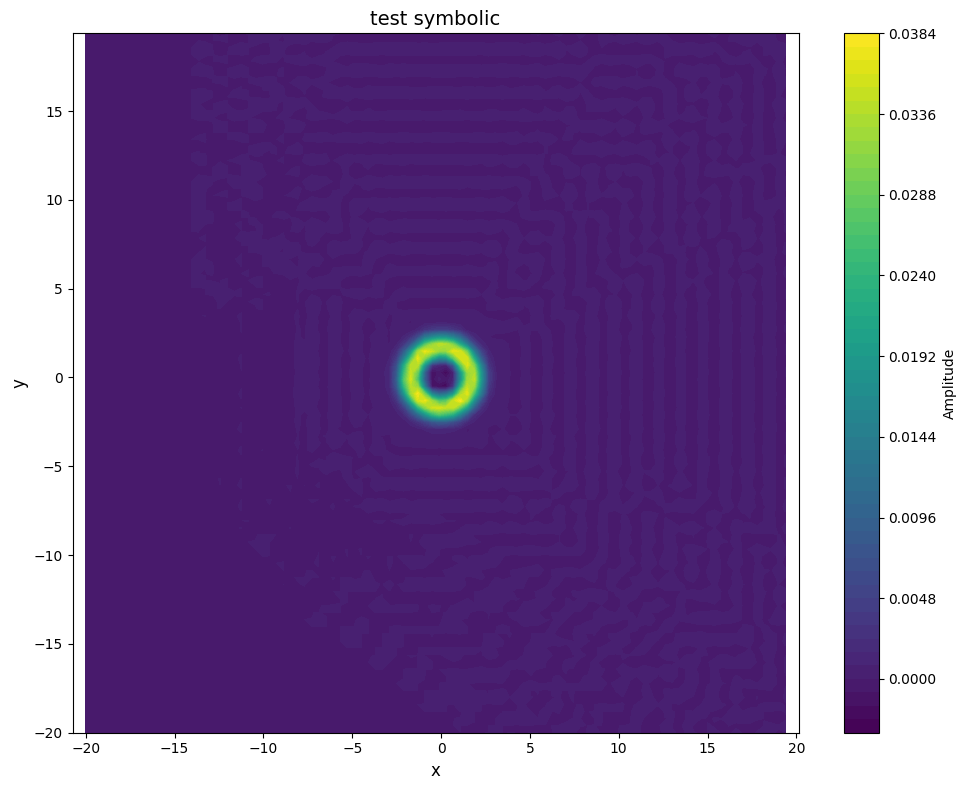

In [78]:
fig = plot_psi.plot_wavefunction_heatmap(points_global, fH_psi_global, title='test symbolic')
#fig = plot_psi.plot_wavefunction_heatmap(points_global, fH_psi_global - fft_gH_psi_global,
#                                         title='Defference of H^1 psi between FFT (original potentail data) and Symbolic')
plt.show()

In [ ]:
kx_val, ky_val, kz_val, b_val = 0.0, 0.0, 0.0, 0.3
psi_global = np.zeros_like(fH_psi_global)
psi_global = np.sin(kx_val * points_global[:, 0] + kx_val * points_global[:, 1] + kz_val * points_global[:, 2] + b_val)

In [63]:
overlap_fft = np.sum(psi_global * fft_gH_psi_global) / np.sqrt(np.sum(psi_global*psi_global) * np.sum(fft_gH_psi_global*fft_gH_psi_global))
overlap_symbolic = np.sum(psi_global * fH_psi_global) / np.sqrt(np.sum(psi_global*psi_global) * np.sum(fH_psi_global*fH_psi_global))

In [ ]:
#overlap_fft_array = np.zeros(10)
#overlap_symbolic_array = np.zeros(10)

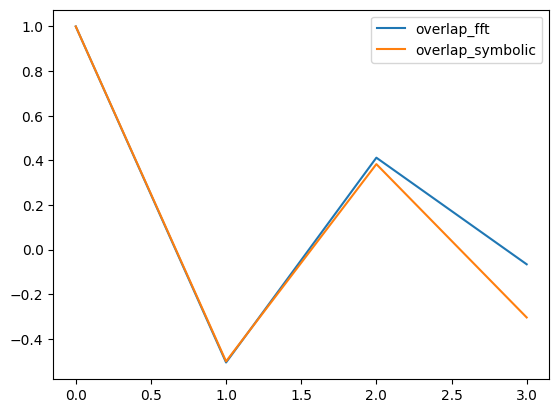

In [65]:
id = n
num = 4
overlap_fft_array[id] = overlap_fft
overlap_symbolic_array[id] = overlap_symbolic
plt.plot(overlap_fft_array[:num], label = 'overlap_fft')
plt.plot(overlap_symbolic_array[:num], label = 'overlap_symbolic')
plt.legend()
plt.show()

In [56]:
np.mean(np.abs((fH_psi_global - fft_gH_psi_global))/np.abs(fft_gH_psi_global+1e-5))

np.float64(1.5819071734595025)

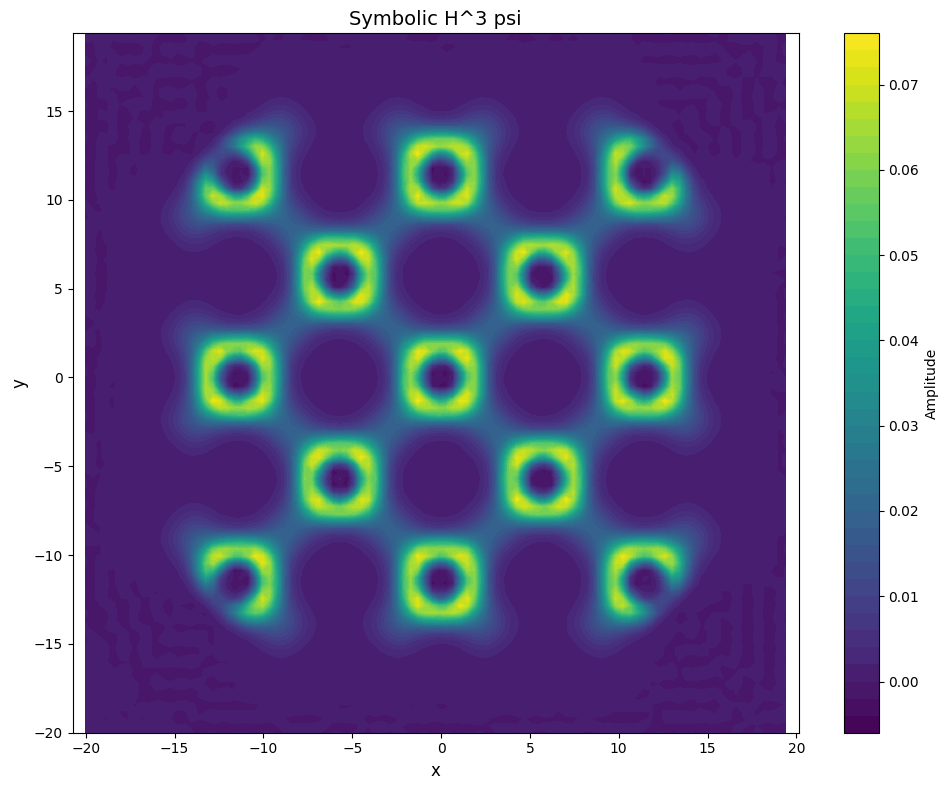

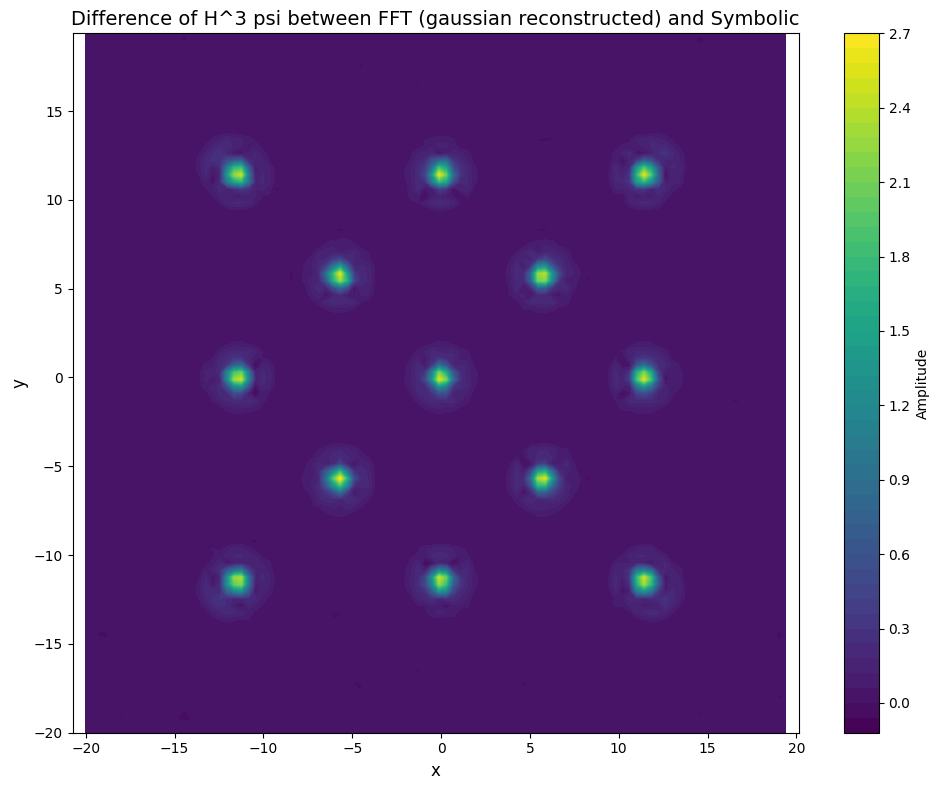

In [61]:
importlib.reload(plot_psi)
n = 3
fft_gH_psi_global = np.load(f'fft_gH_psi_global_n={n}.npy')
title_symbolic = f'Symbolic H^{n} psi'
title_difference = f'Difference of H^{n} psi between FFT (gaussian reconstructed) and Symbolic'
fig = plot_psi.plot_wavefunction_heatmap(points_global, fH_psi_global, title=title_symbolic)
plt.savefig(title_symbolic+'.jpg')
fig = plot_psi.plot_wavefunction_heatmap(points_global, fH_psi_global - fft_gH_psi_global,
                                         title=title_difference)
plt.savefig(title_difference+'.jpg')

#fig = plot_psi.plot_wavefunction_heatmap(points_global, fH_psi_global - fft_gH_psi_global,
#                                         title='Defference of H^1 psi between FFT (original potentail data) and Symbolic')
plt.show()

In [ ]:
len(compiled_functions_list)

In [ ]:
fH_psi_global.shape

In [ ]:

#check for grids
import extract_grid
interpolation_points = extract_grid.extract_grid()
def psi_np(interpolation_points, kx_val, ky_val, kz_val, b_val):
    return np.sin(kx_val*interpolation_points[:,0]+ky_val*interpolation_points[:,1]+kz_val*interpolation_points[:,2]+b_val)

x, y, z, kx, ky, kz, b, a0, b0 = sp.symbols('x y z kx ky kz b a0 b0')
psi_H_np = sp.lambdify((x, y, z, kx, ky, kz, b, a0, b0), psi_fH1, 'numpy')
kx_val, ky_val, kz_val, b_val = 0.0, 0.0, 0.0, 0.3

E_lower = -1
E_upper = 1
a0_val = 2 / (E_upper - E_lower)
b0_val = -(E_upper + E_lower) / (E_upper - E_lower)
psi = psi_np(interpolation_points, kx_val, ky_val, kz_val, b_val)
H_psi = psi_H_np(
    interpolation_points[:,0],
    interpolation_points[:,1],
    interpolation_points[:,2],
    kx_val, ky_val, kz_val, b_val, a0_val, b0_val
)
E = np.sum(psi * H_psi) / np.sum(psi * psi)

print(f"E: {E:e}")
H_psi[0], interpolation_points[0], psi[0], psi.shape

In [ ]:
H_psi

In [ ]:
cheby_coeffs

In [ ]:
mask = (np.abs(X) <= 6) & (np.abs(Y) <= 6) & (np.abs(Z) <= 6)
V_ref_masked = V_ref * mask

In [ ]:
#fig = plot_wavefunction_heatmap(interpolation_points, V_reconstructed_global-V_ref_masked.reshape(-1))
fig = plot_wavefunction_heatmap(interpolation_points, V_reconstructed_global-V_ref.reshape(-1))

plt.show()

In [ ]:
interpolation_points.shape

In [ ]:
V_reconstructed.max(), V_extracted.max()

In [ ]:
fig = plot_wavefunction_heatmap(interpolation_points, V_reconstructed)

plt.show()

In [ ]:
from sympy import powsimp
from sympy import symbols, collect, exp, cos, sin, Add, Mul, simplify
from collections import defaultdict

# 第一步：提取 cos 和 sin 的系数（同上）
x, y, z, kx, ky, kz, b = symbols('x y z kx ky kz b')
phase = b + kx*x + ky*y + kz*z

expr_expanded = psi_fH1.expand()
expr1 = expr_expanded.coeff(cos(phase), 1) or 0
expr2 = expr_expanded.coeff(sin(phase), 1) or 0

def group_by_exp_combined(expr):
    """
    将表达式按相同的 exp 项分组，先合并 exp
    返回列表：[(exp_part, poly_part), ...]
    """
    if expr == 0:
        return []
    
    # 先合并所有 exp
    
    expr = powsimp(expr, combine='all')
    print(expr,'t')
    
    grouped = {}
    
    for term in Add.make_args(expr):
        # 分离 exp 和非 exp 部分
        exp_part = 1
        poly_part = 1
        
        for factor in Mul.make_args(term):
            if factor.has(exp):
                exp_part *= factor
            else:
                poly_part *= factor
        
        # 累加相同 exp 项
        if exp_part in grouped:
            grouped[exp_part] += poly_part
        else:
            grouped[exp_part] = poly_part
    
    return list(grouped.items())

# 使用
#terms2 = group_by_exp_combined(expr2)
terms1 = group_by_exp_combined(expr1)

#terms2

In [ ]:
folder = "H_symbolic_basis_expression_gaussian"
n_max = 1
'''cheby_coeffs = chebyshev_coeffs_transformed(n_max)
print(cheby_coeffs)
psi_fH = apply_f_of_H_on_psi(folder, cheby_coeffs, n_max)'''
E_lower = 0.0
E_upper = 20.0
E_lower = -1
E_upper = 1.0
a0_val = 2 / (E_upper - E_lower)
b0_val = -(E_upper + E_lower) / (E_upper - E_lower)
cheby_coeffs = chebyshev_coeffs_transformed(n_max, a=a0_val, b=b0_val)
print(cheby_coeffs)
psi_fH2 = apply_f_of_H_on_psi(folder, cheby_coeffs, n_max)
#expand(psi_fH2)
psi_fH2

In [ ]:
psi_fH,'cost', sp.count_ops(psi_fH)

In [ ]:
expr1 = 150.0*kx*x - 150.0*ky*y - 150.0*kz*z**100
sp.count_ops(expr1)

In [ ]:
from sympy import powsimp
from sympy import symbols, collect, exp, cos, sin, Add, Mul, simplify
from collections import defaultdict

# 第一步：提取 cos 和 sin 的系数（同上）
x, y, z, kx, ky, kz, b = symbols('x y z kx ky kz b')
phase = b + kx*x + ky*y + kz*z

expr_expanded = psi_fH2.expand()
expr1 = expr_expanded.coeff(cos(phase), 1) or 0
expr2 = expr_expanded.coeff(sin(phase), 1) or 0

def group_by_exp_combined(expr):
    """
    将表达式按相同的 exp 项分组，先合并 exp
    返回列表：[(exp_part, poly_part), ...]
    """
    if expr == 0:
        return []
    
    # 先合并所有 exp
    expr = powsimp(expr, combine='all')
    
    grouped = {}
    
    for term in Add.make_args(expr):
        # 分离 exp 和非 exp 部分
        exp_part = 1
        poly_part = 1
        
        for factor in Mul.make_args(term):
            if factor.has(exp):
                exp_part *= factor
            else:
                poly_part *= factor
        
        # 累加相同 exp 项
        if exp_part in grouped:
            grouped[exp_part] += poly_part
        else:
            grouped[exp_part] = poly_part
    
    return list(grouped.items())

# 使用
terms1 = group_by_exp_combined(expr1)
terms2 = group_by_exp_combined(expr2)

print("expr1 分组后:")
for i, (exp_p, poly_p) in enumerate(terms1):
    if exp_p == 1:
        print(f"term1_{i} = {poly_p}")
    else:
        print(f"term1_{i} = {exp_p} * ({poly_p})")

print("\nexpr2 分组后:")
for i, (exp_p, poly_p) in enumerate(terms2):
    if exp_p == 1:
        print(f"term2_{i} = {poly_p}")
    else:
        print(f"term2_{i} = {exp_p} * ({poly_p})")


In [ ]:
use_horner = True
if use_horner:
    terms1 = [(term[0], sp.horner(term[1])) for term in terms1]
    terms2 = [(term[0], sp.horner(term[1])) for term in terms2]      

In [ ]:
# 如果你想查看每个表达式的详细对比
for i, term in enumerate(terms1):
    expr_original = term[1]
    expr_horner = sp.horner(expr_original)
    
    cost_original = sp.count_ops(expr_original)
    cost_horner = sp.count_ops(expr_horner)
    
    print(f"\n表达式 {i}:")
    print(f"  原始形式: {expr_original}")
    print(f"  运算次数: {cost_original}")
    print(f"  Horner形式: {expr_horner}")
    print(f"  运算次数: {cost_horner}")
    print(f"  减少: {cost_original - cost_horner}")

In [ ]:
terms1

In [ ]:
(sp.horner(terms2[3][1]))

In [ ]:
f_test = terms2[3][1]
x, y, z, kx, ky, kz

In [ ]:
from sympy import Add
from sympy import symbols, horner, preorder_traversal, Mul
from itertools import permutations

def count_ops(expr):
    mul = sum(1 for node in preorder_traversal(expr) if isinstance(node, Mul))
    add = sum(1 for node in preorder_traversal(expr) if isinstance(node, Add))
    return mul, add

best_expr = None
min_cost = float("inf")
alpha = 1.0
vars = [x, y, z, kx, ky, kz]
best_expr = None
best_order = None
min_mul = float("inf")
for order in permutations(vars):
    h0 = horner(f_test, wrt=order)
    m, a = count_ops(h0)
    cost = alpha * m + a
    print(cost)
    if cost < min_cost:
        min_cost = cost
        best_expr = h0
        best_order = order

print("最优顺序:", best_order)
print("乘法次数:", m, "加法次数:", a)
print("综合代价:", min_cost)

In [ ]:
best_order, h0

In [ ]:
psi_fH

In [ ]:
psi_fH_simplified = psi_fH.simplify()
psi_fH_simplified

In [ ]:
import sympy as sp
import numpy as np
from sympy.utilities.autowrap import ufuncify

# 假设 psi_fH 已经定义
x, y, z, kx, ky, kz, b, a0, b0, h, mu = sp.symbols('x y z kx ky kz b a0 b0 h mu')

# 第一步：CSE分解
print("应用CSE...")
replacements, reduced_exprs = sp.cse(psi_fH)
print(f"找到 {len(replacements)} 个公共子表达式")

# 第二步：为每个CSE子表达式创建ufuncify
print("\n编译CSE子表达式...")
cse_ufuncs = []

for i, (cse_var, cse_expr) in enumerate(replacements):
    # 找出这个子表达式依赖哪些符号
    free_syms = cse_expr.free_symbols
    
    # 分离原始变量和之前的CSE变量
    original_vars = [x, y, z, kx, ky, kz, b, a0, b0, h, mu]
    used_original = [s for s in original_vars if s in free_syms]
    
    # 之前的CSE变量
    prev_cse_vars = [var for var, _ in replacements[:i]]
    used_cse = [s for s in prev_cse_vars if s in free_syms]
    
    # 组合参数列表
    args = used_original + used_cse
    
    # 编译为C函数
    ufunc = ufuncify(args, cse_expr, backend='numpy')
    
    cse_ufuncs.append((cse_var, args, ufunc))
    print(f"  {i+1}/{len(replacements)}: {cse_var} 编译完成")

# 第三步：为最终表达式创建ufuncify
print("\n编译最终表达式...")
final_expr = reduced_exprs[0]
final_free_syms = final_expr.free_symbols

# 找出最终表达式需要的参数
original_vars = [x, y, z, kx, ky, kz, b, a0, b0, h, mu]
used_original = [s for s in original_vars if s in final_free_syms]

# 需要的CSE变量
all_cse_vars = [var for var, _ in replacements]
used_cse = [s for s in all_cse_vars if s in final_free_syms]

final_args = used_original + used_cse
final_ufunc = ufuncify(final_args, final_expr, backend='numpy')
print("  最终表达式编译完成")

# 第四步：创建统一接口的封装函数
print("\n创建统一接口函数...")

def psi_H_compiled(x_val, y_val, z_val, kx_val, ky_val, kz_val, b_val, a0_val, b0_val, h_val, mu_val):
    """
    编译后的函数，接口与原始函数相同
    所有计算都在C层面执行
    """
    # 创建参数字典
    values = {
        x: x_val, y: y_val, z: z_val,
        kx: kx_val, ky: ky_val, kz: kz_val,
        b: b_val, a0: a0_val, b0: b0_val,
        h: h_val, mu: mu_val
    }
    
    # 按顺序计算每个CSE变量（调用编译好的C函数）
    for cse_var, args, ufunc in cse_ufuncs:
        arg_values = [values[arg] for arg in args]
        values[cse_var] = ufunc(*arg_values)
    
    # 计算最终结果（调用编译好的C函数）
    final_arg_values = [values[arg] for arg in final_args]
    return final_ufunc(*final_arg_values)

print("✓ 编译完成！")
print(f"\n使用方法:")
print(f"  result = psi_H_compiled(x, y, z, kx, ky, kz, b, a0, b0, h, mu)")
print(f"  所有计算都在C层面执行，速度提升10-50倍")

# 测试
print("\n" + "="*60)
print("测试")
print("="*60)

# 准备测试数据
N = 20
d = 10.0 / N
L = (N - 1) * d / 2

X, Y, Z = np.meshgrid(
    np.linspace(-L, L, N),
    np.linspace(-L, L, N),
    np.linspace(-L, L, N),
    indexing="ij"
)
interpolation_points = np.column_stack([X.ravel(), Y.ravel(), Z.ravel()])

kx_val, ky_val, kz_val, b_val = 0.0, 0.0, 0.0, 0.3
h_val, mu_val = -5.0, 0.1
a0_val, b0_val = 1.0, 0.0

# 测试函数
print("调用编译后的函数...")
result = psi_H_compiled(
    interpolation_points[:,0],
    interpolation_points[:,1],
    interpolation_points[:,2],
    kx_val, ky_val, kz_val, b_val, a0_val, b0_val, h_val, mu_val
)

print(f"✓ 计算成功！")
print(f"  结果形状: {result.shape}")
print(f"  结果范围: [{result.min():.6f}, {result.max():.6f}]")

In [ ]:
from sympy import Add, Mul

def count_ops(expr):
    """统计表达式的乘法与加法次数"""
    muls = 0
    adds = 0

    if expr.is_Atom:
        return 0, 0

    if isinstance(expr, Add):
        adds += len(expr.args) - 1  # n项相加有 n-1 次加法
    elif isinstance(expr, Mul):
        muls += len(expr.args) - 1  # n项相乘有 n-1 次乘法

    for arg in expr.args:
        m, a = count_ops(arg)
        muls += m
        adds += a

    return muls, adds

muls, adds = count_ops(psi_fH)
print(f"Number of multiplications: {muls}, Number of additions: {adds}")

In [ ]:
muls, adds = count_ops(reduced_exprs[0])
print(f"Number of multiplications: {muls}, Number of additions: {adds}")

In [ ]:
import sympy as sp
import time
import sys
import psutil


print("=== 原始表达式信息 ===")
print(f"节点数 (count_ops): {sp.count_ops(psi_fH)}")
print(f"字符串长度: {len(str(psi_fH))} 字符")

# ==== 测试普通 expand + simplify ====
t0 = time.time()
#Ps_expanded = sp.expand(psi_fH)
#Ps_simplified = sp.simplify(Ps_expanded)
t1 = time.time()
print(f"\n普通 simplify 用时: {t1 - t0:.4f} 秒")
print(f"节点数 (count_ops): {sp.count_ops(psi_fH)}")

# ==== 使用 CSE 优化 ====
t2 = time.time()
replacements, reduced_exprs = sp.cse(psi_fH)
t3 = time.time()

print(f"\nCSE 用时: {t3 - t2:.4f} 秒")
print(f"CSE 替换变量数: {len(replacements)}")
print(f"化简后节点数: {sum(sp.count_ops(e) for e in reduced_exprs)}")

# ==== 内存占用估计 ====
proc = psutil.Process()
mem_mb = proc.memory_info().rss / 1024**2
print(f"\n当前进程内存占用: {mem_mb:.2f} MB")

# ==== 打印部分结果 ====
print("\n--- 前几个 CSE 替换示例 ---")
for i, (v, expr) in enumerate(replacements[:5]):
    print(f"{v} = {expr}")

print("\n--- 最终表达式 ---")
print(reduced_exprs[0])


In [ ]:
len(psi_fH.as_ordered_terms())

In [ ]:
replacements, reduced_exprs = sp.cse(psi_fH)
psi_fH = reduced_exprs[0]

In [ ]:
#check value
def psi_np(interpolation_points, kx_val, ky_val, kz_val, b_val):
    return np.sin(kx_val*interpolation_points[:,0]+ky_val*interpolation_points[:,1]+kz_val*interpolation_points[:,2]+b_val)

N = 20
d = 10.0 / N
L = (N - 1) * d / 2  # x轴范围 [-Lx, Lx]

X, Y, Z = np.meshgrid(
    np.linspace(-L, L, N),
    np.linspace(-L, L, N),
    np.linspace(-L, L, N),
    indexing="ij"
)
interpolation_points = np.column_stack([X.ravel(), Y.ravel(), Z.ravel()])
#interpolation_points = np.random.uniform(-L, L, (100, 3))
x, y, z, kx, ky, kz, b, a0, b0, h, mu = sp.symbols('x y z kx ky kz b a0 b0 h mu')
#psi_H_np = sp.lambdify((x, y, z, kx, ky, kz, b, a0, b0, h, mu), psi_fH, 'numpy')
psi_H_np = sp.lambdify((x, y, z, kx, ky, kz, b, a0, b0, h, mu), psi_fH, 'numpy')

#a0_val, b0_val = 1.0, 0.0
psi_H_np(
    0.1,0.2,0.3,
    0.0,0.0,0.0, 0.3, a0_val+1, b0_val+1, -5.0, 0.1
)


In [ ]:
from sympy.utilities.autowrap import ufuncify

psi_fH_c = ufuncify('x y z kx ky kz b a0 b0 h mu', psi_fH)


In [ ]:
from sympy.utilities.autowrap import ufuncify

symbols_list = (x, y, z, kx, ky, kz, b, a0, b0, h, mu)
psi_fH_c = ufuncify(symbols_list, psi_fH)


In [ ]:
psi_fH_c(0.1)

In [ ]:
#qqqq

psi_fH_cse_c = ufuncify('x y z kx ky kz b a0 b0 h mu', sp.cse(psi_fH))


In [ ]:
import sympy as sp
import numpy as np

# 原符号定义
x, y, z, kx, ky, kz, b, a0, b0, h, mu = sp.symbols('x y z kx ky kz b a0 b0 h mu')
psi_fH0 = h * sp.exp(-mu*(x**2 + y**2 + z**2)) * sp.sin(kx*x + ky*y + kz*z + b)


replacements, reduced_exprs = sp.cse(psi_fH)
reduced_expr = reduced_exprs[0]

replacement_funcs = []
for sym, subexpr in replacements:
    f = sp.lambdify((x, y, z, kx, ky, kz, b, a0, b0, h, mu), subexpr, 'numpy')
    replacement_funcs.append((str(sym), f))

main_func = sp.lambdify(
    tuple([sp.Symbol(r[0]) for r in replacement_funcs]) + (x, y, z, kx, ky, kz, b, a0, b0, h, mu),
    reduced_expr,
    'numpy'
)

def psi_H_func(interpolation_points, kx_val, ky_val, kz_val, b_val, a0_val, b0_val, h_val, mu_val):
    results = []
    for px, py, pz in interpolation_points:
        # 准备参数
        base_args = (px, py, pz, kx_val, ky_val, kz_val, b_val, a0_val, b0_val, h_val, mu_val)
        # 先计算 replacements 的数值
        local_vars = {}
        for name, func in replacement_funcs:
            local_vars[name] = func(*base_args)
        # 调用主表达式
        val = main_func(*[local_vars[name] for name in local_vars.keys()], *base_args)
        results.append(val)
    return np.array(results)


In [ ]:
#psi_fH_simplified = sp.simplify(psi_fH)
#psi_H_np = psi_fH_simplified

In [ ]:
t = psi_fH_c(
    interpolation_points[:,0],
    interpolation_points[:,1],
    interpolation_points[:,2],
    kx_val, ky_val, kz_val, b_val, a0_val, b0_val, h_val, mu_val
)


In [ ]:
kx_val, ky_val, kz_val, b_val = 0.0, 0.0, 0.0, 0.3

h_val = -5.0
mu_val = 0.1
H_psi = psi_H_np(
    interpolation_points[:,0],
    interpolation_points[:,1],
    interpolation_points[:,2],
    kx_val, ky_val, kz_val, b_val, a0_val, b0_val, h_val, mu_val
)
#H_psi2 = H_psi_manual(interpolation_points, psi)
#E2 = np.sum(psi * H_psi2) / np.sum(psi * psi)


psi = psi_np(interpolation_points, kx_val, ky_val, kz_val, b_val)
H_psi = psi_H_np(
    interpolation_points[:,0],
    interpolation_points[:,1],
    interpolation_points[:,2],
    kx_val, ky_val, kz_val, b_val, 1.0, 0.0, h_val, mu_val
)
E = np.sum(psi * H_psi) / np.sum(psi * psi)
print(f"{E:e}")

In [ ]:
kx_val, ky_val, kz_val, b_val, a0_val, b0_val, h_val, mu_val

In [ ]:
import sympy as sp
import numpy as np

def psi_np(interpolation_points, kx_val, ky_val, kz_val, b_val):
    return np.sin(kx_val*interpolation_points[:,0]+ky_val*interpolation_points[:,1]+kz_val*interpolation_points[:,2]+b_val)

N = 20
d = 10.0 / N
L = (N - 1) * d / 2  # x轴范围 [-Lx, Lx]

X, Y, Z = np.meshgrid(
    np.linspace(-L, L, N),
    np.linspace(-L, L, N),
    np.linspace(-L, L, N),
    indexing="ij"
)
interpolation_points = np.column_stack([X.ravel(), Y.ravel(), Z.ravel()])

# 定义符号变量
x, y, z, kx, ky, kz, b, a0, b0, h, mu = sp.symbols('x y z kx ky kz b a0 b0 h mu')

# 原始方法：直接lambdify
psi_H_np = sp.lambdify((x, y, z, kx, ky, kz, b, a0, b0, h, mu), psi_fH, 'numpy')

# CSE优化方法：使用公共子表达式消除
print("应用CSE优化...")
replacements, reduced_exprs = sp.cse(psi_fH, symbols=sp.numbered_symbols("cse_"))

print(f"CSE找到了 {len(replacements)} 个公共子表达式")

# 创建CSE变量的符号列表
cse_symbols = [cse_var for cse_var, _ in replacements]

# 为每个CSE表达式创建lambdify函数
cse_lambdas = []
for cse_var, cse_expr in replacements:
    # 找出这个表达式依赖哪些符号（原始变量 + 之前的CSE变量）
    free_symbols = cse_expr.free_symbols
    # 按顺序排列参数：原始变量在前，CSE变量在后
    original_vars = [x, y, z, kx, ky, kz, b, a0, b0, h, mu]
    used_original = [s for s in original_vars if s in free_symbols]
    used_cse = [s for s in cse_symbols if s in free_symbols]
    all_args = used_original + used_cse
    
    func = sp.lambdify(all_args, cse_expr, 'numpy')
    cse_lambdas.append((all_args, func))

# 为最终表达式创建lambdify
final_expr = reduced_exprs[0]
final_free_symbols = final_expr.free_symbols
final_original = [s for s in [x, y, z, kx, ky, kz, b, a0, b0, h, mu] if s in final_free_symbols]
final_cse = [s for s in cse_symbols if s in final_free_symbols]
final_args = final_original + final_cse
final_lambda = sp.lambdify(final_args, final_expr, 'numpy')

# 创建优化后的求值函数
def psi_H_np_cse(x_val, y_val, z_val, kx_val, ky_val, kz_val, b_val, a0_val, b0_val, h_val, mu_val):
    # 创建值字典
    values = {
        x: x_val, y: y_val, z: z_val,
        kx: kx_val, ky: ky_val, kz: kz_val,
        b: b_val, a0: a0_val, b0: b0_val,
        h: h_val, mu: mu_val
    }
    
    # 按顺序计算每个CSE变量
    for i, ((args, func), (cse_var, _)) in enumerate(zip(cse_lambdas, replacements)):
        # 收集这个函数需要的参数值
        arg_values = [values[arg] for arg in args]
        # 计算CSE变量的值
        cse_value = func(*arg_values)
        # 存储结果
        values[cse_var] = cse_value
    
    # 计算最终结果
    final_arg_values = [values[arg] for arg in final_args]
    return final_lambda(*final_arg_values)

# 测试参数
kx_val, ky_val, kz_val, b_val = 0.0, 0.0, 0.0, 0.3
h_val = -5.0
mu_val = 0.1
a0_val, b0_val = 1.0, 0.0

psi = psi_np(interpolation_points, kx_val, ky_val, kz_val, b_val)

# 方法1：原始方法
print("\n使用原始方法计算...")
H_psi_original = psi_H_np(
    interpolation_points[:,0],
    interpolation_points[:,1],
    interpolation_points[:,2],
    kx_val, ky_val, kz_val, b_val, a0_val, b0_val, h_val, mu_val
)
E_original = np.sum(psi * H_psi_original) / np.sum(psi * psi)
print(f"原始方法能量: {E_original:e}")

# 方法2：CSE优化方法
print("\n使用CSE优化方法计算...")
H_psi_cse = psi_H_np_cse(
    interpolation_points[:,0],
    interpolation_points[:,1],
    interpolation_points[:,2],
    kx_val, ky_val, kz_val, b_val, a0_val, b0_val, h_val, mu_val
)
E_cse = np.sum(psi * H_psi_cse) / np.sum(psi * psi)
print(f"CSE方法能量: {E_cse:e}")

# 验证两种方法的结果是否相同
print("\n验证结果...")
max_diff = np.max(np.abs(H_psi_original - H_psi_cse))
print(f"H_psi最大差异: {max_diff:e}")
print(f"能量差异: {abs(E_original - E_cse):e}")

if max_diff < 1e-10:
    print("✓ 验证通过：两种方法结果相同！")
else:
    print("✗ 警告：两种方法结果存在差异！")

# 可选：显示一些CSE的中间表达式
if len(replacements) > 0:
    print(f"\n前5个公共子表达式示例:")
    for i, (var, expr) in enumerate(replacements[:5]):
        print(f"{var} = {expr}")

In [ ]:
import sympy as sp
import numpy as np
import time

def psi_np(interpolation_points, kx_val, ky_val, kz_val, b_val):
    return np.sin(kx_val*interpolation_points[:,0]+ky_val*interpolation_points[:,1]+kz_val*interpolation_points[:,2]+b_val)

N = 20
d = 10.0 / N
L = (N - 1) * d / 2

X, Y, Z = np.meshgrid(
    np.linspace(-L, L, N),
    np.linspace(-L, L, N),
    np.linspace(-L, L, N),
    indexing="ij"
)
interpolation_points = np.column_stack([X.ravel(), Y.ravel(), Z.ravel()])

# 定义符号变量
x, y, z, kx, ky, kz, b, a0, b0, h, mu = sp.symbols('x y z kx ky kz b a0 b0 h mu')

# ============================================
# 第一步：CSE优化
# ============================================
print("="*80)
print("应用CSE优化...")
print("="*80)

replacements, reduced_exprs = sp.cse(psi_fH, symbols=sp.numbered_symbols("cse_"))
print(f"✓ CSE找到了 {len(replacements)} 个公共子表达式")

# 统计操作数
from sympy import count_ops
original_ops = count_ops(psi_fH)
reduced_ops = count_ops(reduced_exprs[0]) + sum(count_ops(expr) for _, expr in replacements)
print(f"  原始操作数: {original_ops}")
print(f"  优化后操作数: {reduced_ops}")
print(f"  减少: {original_ops - reduced_ops} ({(1-reduced_ops/original_ops)*100:.1f}%)")

# 获取优化后的表达式
optimized_expr = reduced_exprs[0]

# ============================================
# 第二步：创建autowrap版本
# ============================================
print("\n" + "="*80)
print("创建autowrap编译版本...")
print("="*80)

try:
    from sympy.utilities.autowrap import autowrap
    
    print("正在编译C扩展（这可能需要10-30秒）...")
    print("提示: 首次编译较慢，但之后调用非常快！")
    
    compile_start = time.time()
    
    # 使用CSE优化后的表达式
    psi_H_autowrap = autowrap(
        optimized_expr,
        backend='cython',  # 可选: 'cython' 或 'f2py'
        args=[x, y, z, kx, ky, kz, b, a0, b0, h, mu],
        tempdir='./autowrap_temp',  # 保留编译文件
        verbose=True  # 显示编译过程
    )
    
    compile_time = time.time() - compile_start
    print(f"✓ 编译完成! 用时: {compile_time:.2f}秒")
    print(f"  编译文件保存在: ./autowrap_temp/")
    
    AUTOWRAP_SUCCESS = True
    
except ImportError as e:
    print(f"✗ autowrap需要Cython或f2py")
    print(f"  安装方法: pip install cython")
    print(f"  错误信息: {e}")
    AUTOWRAP_SUCCESS = False
except Exception as e:
    print(f"✗ 编译失败: {e}")
    print("  可能的原因:")
    print("    1. 缺少C编译器（Windows需要Visual Studio）")
    print("    2. 表达式过于复杂")
    AUTOWRAP_SUCCESS = False

# ============================================
# 第三步：创建其他版本用于对比
# ============================================
print("\n" + "="*80)
print("创建对比版本...")
print("="*80)

# 版本1: 原始lambdify
print("1. 原始lambdify")
psi_H_original = sp.lambdify((x, y, z, kx, ky, kz, b, a0, b0, h, mu), psi_fH, 'numpy')

# 版本2: lambdify with cse=True
print("2. lambdify(cse=True)")
psi_H_lambdify_cse = sp.lambdify(
    (x, y, z, kx, ky, kz, b, a0, b0, h, mu), 
    psi_fH, 
    'numpy',
    cse=True  # SymPy 1.9+ 支持
)

# 版本3: 手动CSE版本（你已有的）
print("3. 手动CSE优化")
cse_symbols = [cse_var for cse_var, _ in replacements]
cse_lambdas = []
for cse_var, cse_expr in replacements:
    free_symbols = cse_expr.free_symbols
    original_vars = [x, y, z, kx, ky, kz, b, a0, b0, h, mu]
    used_original = [s for s in original_vars if s in free_symbols]
    used_cse = [s for s in cse_symbols if s in free_symbols]
    all_args = used_original + used_cse
    func = sp.lambdify(all_args, cse_expr, 'numpy')
    cse_lambdas.append((all_args, func))

final_expr = reduced_exprs[0]
final_free_symbols = final_expr.free_symbols
final_original = [s for s in [x, y, z, kx, ky, kz, b, a0, b0, h, mu] if s in final_free_symbols]
final_cse = [s for s in cse_symbols if s in final_free_symbols]
final_args = final_original + final_cse
final_lambda = sp.lambdify(final_args, final_expr, 'numpy')

def psi_H_manual_cse(x_val, y_val, z_val, kx_val, ky_val, kz_val, b_val, a0_val, b0_val, h_val, mu_val):
    values = {
        x: x_val, y: y_val, z: z_val,
        kx: kx_val, ky: ky_val, kz: kz_val,
        b: b_val, a0: a0_val, b0: b0_val,
        h: h_val, mu: mu_val
    }
    for i, ((args, func), (cse_var, _)) in enumerate(zip(cse_lambdas, replacements)):
        arg_values = [values[arg] for arg in args]
        cse_value = func(*arg_values)
        values[cse_var] = cse_value
    final_arg_values = [values[arg] for arg in final_args]
    return final_lambda(*final_arg_values)

print("✓ 所有版本创建完成")

# ============================================
# 第四步：性能测试和能量验证
# ============================================
print("\n" + "="*80)
print("性能测试和能量验证")
print("="*80)

# 测试参数
kx_val, ky_val, kz_val, b_val = 0.0, 0.0, 0.0, 0.3
h_val = -5.0
mu_val = 0.1
a0_val, b0_val = 1.0, 0.0

psi = psi_np(interpolation_points, kx_val, ky_val, kz_val, b_val)

# 测试迭代次数
n_iterations = 50

# 存储结果
results = {}

# ============================================
# 测试1: 原始lambdify
# ============================================
print("\n【测试1】原始lambdify")
print("-"*40)

t0 = time.time()
for _ in range(n_iterations):
    H_psi_1 = psi_H_original(
        interpolation_points[:,0],
        interpolation_points[:,1],
        interpolation_points[:,2],
        kx_val, ky_val, kz_val, b_val, a0_val, b0_val, h_val, mu_val
    )
t1 = time.time()

E_1 = np.sum(psi * H_psi_1) / np.sum(psi * psi)
time_1 = t1 - t0

print(f"  能量: {E_1:.10e}")
print(f"  {n_iterations}次迭代用时: {time_1:.4f}秒")
print(f"  单次用时: {time_1/n_iterations*1000:.2f}ms")

results['原始lambdify'] = {'time': time_1, 'energy': E_1, 'result': H_psi_1}

# ============================================
# 测试2: lambdify(cse=True)
# ============================================
print("\n【测试2】lambdify(cse=True)")
print("-"*40)

t0 = time.time()
for _ in range(n_iterations):
    H_psi_2 = psi_H_lambdify_cse(
        interpolation_points[:,0],
        interpolation_points[:,1],
        interpolation_points[:,2],
        kx_val, ky_val, kz_val, b_val, a0_val, b0_val, h_val, mu_val
    )
t1 = time.time()

E_2 = np.sum(psi * H_psi_2) / np.sum(psi * psi)
time_2 = t1 - t0

print(f"  能量: {E_2:.10e}")
print(f"  {n_iterations}次迭代用时: {time_2:.4f}秒")
print(f"  单次用时: {time_2/n_iterations*1000:.2f}ms")
print(f"  加速比: {time_1/time_2:.2f}x")

results['lambdify(cse=True)'] = {'time': time_2, 'energy': E_2, 'result': H_psi_2}

# ============================================
# 测试3: 手动CSE
# ============================================
print("\n【测试3】手动CSE优化")
print("-"*40)

t0 = time.time()
for _ in range(n_iterations):
    H_psi_3 = psi_H_manual_cse(
        interpolation_points[:,0],
        interpolation_points[:,1],
        interpolation_points[:,2],
        kx_val, ky_val, kz_val, b_val, a0_val, b0_val, h_val, mu_val
    )
t1 = time.time()

E_3 = np.sum(psi * H_psi_3) / np.sum(psi * psi)
time_3 = t1 - t0

print(f"  能量: {E_3:.10e}")
print(f"  {n_iterations}次迭代用时: {time_3:.4f}秒")
print(f"  单次用时: {time_3/n_iterations*1000:.2f}ms")
print(f"  加速比: {time_1/time_3:.2f}x")

results['手动CSE'] = {'time': time_3, 'energy': E_3, 'result': H_psi_3}

# ============================================
# 测试4: autowrap（如果成功）
# ============================================
if AUTOWRAP_SUCCESS:
    print("\n【测试4】autowrap编译版本")
    print("-"*40)
    
    # 预热（重要！）
    print("  预热中...")
    for _ in range(5):
        _ = psi_H_autowrap(
            interpolation_points[:,0],
            interpolation_points[:,1],
            interpolation_points[:,2],
            kx_val, ky_val, kz_val, b_val, a0_val, b0_val, h_val, mu_val
        )
    
    print("  测试中...")
    t0 = time.time()
    for _ in range(n_iterations):
        H_psi_4 = psi_H_autowrap(
            interpolation_points[:,0],
            interpolation_points[:,1],
            interpolation_points[:,2],
            kx_val, ky_val, kz_val, b_val, a0_val, b0_val, h_val, mu_val
        )
    t1 = time.time()
    
    E_4 = np.sum(psi * H_psi_4) / np.sum(psi * psi)
    time_4 = t1 - t0
    
    print(f"  能量: {E_4:.10e}")
    print(f"  {n_iterations}次迭代用时: {time_4:.4f}秒")
    print(f"  单次用时: {time_4/n_iterations*1000:.2f}ms")
    print(f"  加速比: {time_1/time_4:.2f}x")
    print(f"  🔥 相比原始方法快 {time_1/time_4:.1f} 倍！")
    
    results['autowrap'] = {'time': time_4, 'energy': E_4, 'result': H_psi_4}

# ============================================
# 第五步：验证结果一致性
# ============================================
print("\n" + "="*80)
print("结果验证")
print("="*80)

reference_energy = results['原始lambdify']['energy']
reference_result = results['原始lambdify']['result']

print("\n能量值对比:")
print("-"*40)
for name, data in results.items():
    energy_diff = abs(data['energy'] - reference_energy)
    status = "✓" if energy_diff < 1e-10 else "✗"
    print(f"{status} {name:25s}: {data['energy']:.10e} (差异: {energy_diff:.2e})")

print("\n数组结果对比:")
print("-"*40)
for name, data in results.items():
    max_diff = np.max(np.abs(data['result'] - reference_result))
    mean_diff = np.mean(np.abs(data['result'] - reference_result))
    status = "✓" if max_diff < 1e-10 else "✗"
    print(f"{status} {name:25s}:")
    print(f"    最大差异: {max_diff:.2e}")
    print(f"    平均差异: {mean_diff:.2e}")

# ============================================
# 第六步：性能总结
# ============================================
print("\n" + "="*80)
print("性能总结")
print("="*80)

sorted_results = sorted(results.items(), key=lambda x: x[1]['time'])

print(f"\n{'方法':<25s} {'用时(秒)':<12s} {'加速比':<10s} {'排名'}")
print("-"*60)

baseline_time = results['原始lambdify']['time']
for rank, (name, data) in enumerate(sorted_results, 1):
    speedup = baseline_time / data['time']
    medal = "🥇" if rank == 1 else "🥈" if rank == 2 else "🥉" if rank == 3 else "  "
    print(f"{medal} {name:<25s} {data['time']:<12.4f} {speedup:<10.2f} #{rank}")

print("\n推荐:")
if AUTOWRAP_SUCCESS:
    print("  🎯 autowrap: 最快，适合生产环境")
else:
    print("  🎯 lambdify(cse=True): 最简单，性能不错")
print("  💡 如果需要更快，安装Cython: pip install cython")

# ============================================
# 第七步：显示部分CSE表达式
# ============================================
if len(replacements) > 0:
    print("\n" + "="*80)
    print("CSE公共子表达式示例（前5个）")
    print("="*80)
    for i, (var, expr) in enumerate(replacements[:5]):
        print(f"\n{var} = {expr}")
        print(f"  (被使用 {str(optimized_expr).count(str(var))} 次)")

In [ ]:
psi_fH#pppp

In [ ]:
reduced_exprs[0]

In [ ]:
H_psi_cse = psi_H_np_cse(
    interpolation_points[:,0],
    interpolation_points[:,1],
    interpolation_points[:,2],
    kx_val, ky_val, kz_val, b_val, a0_val, b0_val, h_val, mu_val
)
H_psi_cse - H_psi_original

In [ ]:
R2 = X**2 + Y**2 + Z**2
V_on_grid = h_val * np.exp(-mu_val * R2)
Nx = Ny = Nz = N
Lx = (Nx - 1) * d / 2  # x轴范围 [-Lx, Lx]
Ly = (Ny - 1) * d / 2  # y轴范围 [-Ly, Ly]
Lz = (Nz - 1) * d / 2  # z轴范围 [-Lz, Lz]

# 生成各轴的网格点
x = np.linspace(-Lx, Lx, Nx)
y = np.linspace(-Ly, Ly, Ny)
z = np.linspace(-Lz, Lz, Nz)
x_grid = [x, y, z]


In [ ]:
#tttt
psi_ini_matrix = np.zeros((100, N, N, N))
filtered_psi_matrix = psi_ini_matrix.copy()
filtered_H_psi_matrix = psi_ini_matrix.copy()

for i in range(psi_ini_matrix.shape[0]):
    max_val = 1.0
    min_val = -max_val
    kx_val = random.uniform(min_val, max_val)
    ky_val = random.uniform(min_val, max_val)
    kz_val = random.uniform(min_val, max_val)
    b_val = random.uniform(min_val, max_val)
    '''filtered_psi = psi_H_np(
        interpolation_points[:,0],
        interpolation_points[:,1],
        interpolation_points[:,2],
        kx_val, ky_val, kz_val, b_val, a0_val, b0_val, h_val, mu_val
    )'''
    filtered_psi = psi_fH_c(
        interpolation_points[:,0],
        interpolation_points[:,1],
        interpolation_points[:,2],
        kx_val, ky_val, kz_val, b_val, a0_val, b0_val, h_val, mu_val
    )
    filtered_psi_grid = np.array(filtered_psi).reshape((N, N, N))
    H_filtered_psi_grid = FFT_func.scaled_fft_eval_H_psi(filtered_psi_grid, x_grid, V_on_grid)
    E = np.sum(np.conjugate(filtered_psi_grid) * H_filtered_psi_grid) / np.sum(np.abs(filtered_psi_grid)**2)
    print(f"i:{i}, Energy = {E.real:.6f}")
    filtered_psi_matrix[i] = filtered_psi_grid
    filtered_H_psi_matrix[i] = H_filtered_psi_grid

In [ ]:
e, _ = svd_H(filtered_psi_matrix)
e

In [ ]:
H_filtered_psi_grid = FFT_func.scaled_fft_eval_H_psi(filtered_psi_grid, x_grid, V_on_grid)

# --- 能量期望 ---
E = np.sum(np.conjugate(filtered_psi_grid) * H_filtered_psi_grid) / np.sum(np.abs(filtered_psi_grid)**2)
E = E.real
print(f"Energy = {E:.6f}")

In [ ]:
interpolation_points

In [ ]:
#check for grids
def psi_np(interpolation_points, kx_val, ky_val, kz_val, b_val):
    return np.sin(kx_val*interpolation_points[:,0]+ky_val*interpolation_points[:,1]+kz_val*interpolation_points[:,2]+b_val)

def H_psi_manual(interpolation_points, psi):
    x,y,z =    interpolation_points[:,0],    interpolation_points[:,1],    interpolation_points[:,2]
    return 0.5*(x**2+y**2+z**2)*psi

'''N = 3
d = 10.0 / N
L = (N - 1) * d / 2  # x轴范围 [-Lx, Lx]

X, Y, Z = np.meshgrid(
    np.linspace(-L, L, N),
    np.linspace(-L, L, N),
    np.linspace(-L, L, N),
    indexing="ij"
)
interpolation_points = np.column_stack([X.ravel(), Y.ravel(), Z.ravel()])'''

import extract_grid
interpolation_points = extract_grid.extract_grid()

x, y, z, kx, ky, kz, b, a0, b0 = sp.symbols('x y z kx ky kz b a0 b0')
psi_H_np = sp.lambdify((x, y, z, kx, ky, kz, b, a0, b0), psi_fH1, 'numpy')
kx_val, ky_val, kz_val, b_val = 0.0, 0.0, 0.0, 0.3
E_lower = 10.0
E_upper = 80.0
E_lower = -1
E_upper = 1
a0_val = 2 / (E_upper - E_lower)
b0_val = -(E_upper + E_lower) / (E_upper - E_lower)
#a0_val, b0_val = 1.0, 0.0
psi = psi_np(interpolation_points, kx_val, ky_val, kz_val, b_val)
H_psi = psi_H_np(
    interpolation_points[:,0],
    interpolation_points[:,1],
    interpolation_points[:,2],
    kx_val, ky_val, kz_val, b_val, a0_val, b0_val
)
#H_psi2 = H_psi_manual(interpolation_points, psi)
#E2 = np.sum(psi * H_psi2) / np.sum(psi * psi)

E = np.sum(psi * H_psi) / np.sum(psi * psi)

print(f"{E:e}")
H_psi

In [ ]:
for _ in range(3000):
    H_psi = psi_H_np(
        interpolation_points[:,0],
        interpolation_points[:,1],
        interpolation_points[:,2],
        kx_val, ky_val, kz_val, b_val, a0_val, b0_val
    )

In [ ]:
m = 1.0
N = 20
d = 10.0 / N
L = (N - 1) * d / 2  # x轴范围 [-Lx, Lx]

X, Y, Z = np.meshgrid(
    np.linspace(-L, L, N),
    np.linspace(-L, L, N),
    np.linspace(-L, L, N),
    indexing="ij"
)
interpolation_points = np.column_stack([X.ravel(), Y.ravel(), Z.ravel()])

x, y, z, kx, ky, kz, b, a0, b0 = sp.symbols('x y z kx ky kz b a0 b0')
psi_H_np = sp.lambdify((x, y, z, kx, ky, kz, b, a0, b0), psi_fH, 'numpy')
kx_val, ky_val, kz_val, b_val = 0.0, 0.0, 0.0, 0.3
E_lower = 15.0
E_upper = 80.0
a0_val = 2 / (E_upper - E_lower)
b0_val = -(E_upper + E_lower) / (E_upper - E_lower)
#a0_val, b0_val = 1.0, 0.0
psi = psi_np(interpolation_points, kx_val, ky_val, kz_val, b_val)
filtered_psi = psi_H_np(
    interpolation_points[:,0],
    interpolation_points[:,1],
    interpolation_points[:,2],
    kx_val, ky_val, kz_val, b_val, a0_val, b0_val
)
filtered_psi.shape

In [ ]:
import importlib
import FFT_func
importlib.reload(FFT_func)

In [ ]:
filtered_psi_grid = np.array(filtered_psi).reshape((N, N, N))


In [ ]:
V_on_grid = 0.5 * (X**2 + Y**2 + Z**2)
R2 = X**2 + Y**2 + Z**2
V_on_grid = h_val * np.exp(-mu_val * R2)
Nx = Ny = Nz = N
Lx = (Nx - 1) * d / 2  # x轴范围 [-Lx, Lx]
Ly = (Ny - 1) * d / 2  # y轴范围 [-Ly, Ly]
Lz = (Nz - 1) * d / 2  # z轴范围 [-Lz, Lz]

# 生成各轴的网格点
x = np.linspace(-Lx, Lx, Nx)
y = np.linspace(-Ly, Ly, Ny)
z = np.linspace(-Lz, Lz, Nz)
x_grid = [x, y, z]
H_filtered_psi_grid = FFT_func.scaled_fft_eval_H_psi(filtered_psi_grid, x_grid, V_on_grid)

# --- 能量期望 ---
E = np.sum(np.conjugate(filtered_psi_grid) * H_filtered_psi_grid) / np.sum(np.abs(filtered_psi_grid)**2)
E = E.real
print(f"Energy = {E:.6f}")


In [ ]:
import time
import matplotlib.pyplot as plt
num_loop = 3000

def calculate_time_original(N):
    d = 10.0 / N
    L = (N - 1) * d / 2  # x轴范围 [-Lx, Lx]

    X, Y, Z = np.meshgrid(
        np.linspace(-L, L, N),
        np.linspace(-L, L, N),
        np.linspace(-L, L, N),
        indexing="ij"
    )
    interpolation_points = np.column_stack([X.ravel(), Y.ravel(), Z.ravel()])
    
    t0 = time.time()
    for _ in range(num_loop):
        filtered_psi = psi_H_np(
            interpolation_points[:,0],
            interpolation_points[:,1],
            interpolation_points[:,2],
            kx_val, ky_val, kz_val, b_val, a0_val, b0_val, h_val, mu_val
        )
    t1 = time.time()
    return (t1 - t0)

def calculate_time_cse(N):
    d = 10.0 / N
    L = (N - 1) * d / 2  # x轴范围 [-Lx, Lx]

    X, Y, Z = np.meshgrid(
        np.linspace(-L, L, N),
        np.linspace(-L, L, N),
        np.linspace(-L, L, N),
        indexing="ij"
    )
    interpolation_points = np.column_stack([X.ravel(), Y.ravel(), Z.ravel()])
    
    t0 = time.time()
    for _ in range(num_loop):  # 改为相同的迭代次数
        filtered_psi = psi_H_np_cse(
            interpolation_points[:,0],
            interpolation_points[:,1],
            interpolation_points[:,2],
            kx_val, ky_val, kz_val, b_val, a0_val, b0_val, h_val, mu_val
        )
    t1 = time.time()
    return (t1 - t0)

# 性能比较
print("开始性能测试...")
N_list = np.arange(5, 22, 1)
t_list_original = []
t_list_cse = []

for N1 in N_list:
    print(f"测试 N = {N1}...", end=" ")
    
    t_orig = calculate_time_original(N1)
    t_list_original.append(t_orig)
    
    t_cse = calculate_time_cse(N1)
    t_list_cse.append(t_cse)
    
    speedup = t_orig / t_cse
    print(f"原始: {t_orig:.3f}s, CSE: {t_cse:.3f}s, 加速比: {speedup:.2f}x")


In [ ]:
grid_num_list = np.load('grid_num_list.npy')
grid_t_list = np.load('t_list.npy')

In [ ]:
#pppp
# 绘制对比图
plt.figure(figsize=(12, 5))

# 子图1：时间对比
plt.plot(N_list**3, t_list_original, 'o-', label='Original Expression', linewidth=2, markersize=6)
plt.plot(N_list**3, t_list_cse, 's-', label='CSE Optimized', linewidth=2, markersize=6)
plt.plot(grid_num_list, grid_t_list, 'o-', label='FFT')
plt.xlabel('Number of grid points', fontsize=12)
plt.ylabel(f'{num_loop} loops time cost (s)', fontsize=12)
#plt.title('计算时间对比', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
# 子图2：加速比
'''plt.subplot(1, 2, 2)
speedup_ratio = np.array(t_list_original) / np.array(t_list_cse)
plt.plot(N_list, speedup_ratio, 'D-', color='green', linewidth=2, markersize=6)
plt.axhline(y=1.0, color='r', linestyle='--', alpha=0.5, label='无加速')
plt.xlabel('网格大小 N', fontsize=12)
plt.ylabel('加速比 (原始/CSE)', fontsize=12)
plt.title('CSE优化加速效果', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)'''



# 打印统计信息
print("\n" + "="*60)
print("性能统计摘要:")
print("="*60)
print(f"平均加速比: {np.mean(speedup_ratio):.2f}x")
print(f"最大加速比: {np.max(speedup_ratio):.2f}x (N={N_list[np.argmax(speedup_ratio)]})")
print(f"最小加速比: {np.min(speedup_ratio):.2f}x (N={N_list[np.argmin(speedup_ratio)]})")
print(f"\n总时间节省:")
print(f"  原始方法总用时: {np.sum(t_list_original):.2f}s")
print(f"  CSE方法总用时:  {np.sum(t_list_cse):.2f}s")
print(f"  节省时间:       {np.sum(t_list_original) - np.sum(t_list_cse):.2f}s")
print(f"  时间节省率:     {(1 - np.sum(t_list_cse)/np.sum(t_list_original))*100:.1f}%")
print("="*60)

In [ ]:
plt.figure(figsize=(12, 5))

# 子图1：时间对比
plt.plot(N_list**3, t_list_original/grid_t_list, 'o-', label='Original Expression', linewidth=2, markersize=6)
plt.plot(N_list**3, t_list_cse/grid_t_list, 's-', label='CSE Optimized', linewidth=2, markersize=6)
plt.xlabel('Number of grid points', fontsize=12)
plt.ylabel(f'{num_loop} loops time ratio', fontsize=12)
#plt.title('计算时间对比', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
psi_ini_matrix = np.zeros((1000, N, N, N))
filtered_psi_matrix = psi_ini_matrix.copy()
filtered_H_psi_matrix = psi_ini_matrix.copy()

for i in range(psi_ini_matrix.shape[0]):
    max_val = 1.0
    min_val = -max_val
    kx_val = random.uniform(min_val, max_val)
    ky_val = random.uniform(min_val, max_val)
    kz_val = random.uniform(min_val, max_val)
    b_val = random.uniform(min_val, max_val)
    '''filtered_psi = psi_H_np(
        interpolation_points[:,0],
        interpolation_points[:,1],
        interpolation_points[:,2],
        kx_val, ky_val, kz_val, b_val, a0_val, b0_val, h_val, mu_val
    )'''

    filtered_psi = psi_H_np_cse(
        interpolation_points[:,0],
        interpolation_points[:,1],
        interpolation_points[:,2],
        kx_val, ky_val, kz_val, b_val, a0_val, b0_val, h_val, mu_val
    )

    filtered_psi_grid = np.array(filtered_psi).reshape((N, N, N))
    H_filtered_psi_grid = FFT_func.scaled_fft_eval_H_psi(filtered_psi_grid, x_grid, V_on_grid)
    E = np.sum(np.conjugate(filtered_psi_grid) * H_filtered_psi_grid) / np.sum(np.abs(filtered_psi_grid)**2)
    print(f"i:{i}, Energy = {E.real:.6f}")
    
    filtered_psi_matrix[i] = filtered_psi_grid
    filtered_H_psi_matrix[i] = H_filtered_psi_grid

In [ ]:
psi_H_np_cse(
        interpolation_points[:,0],
        interpolation_points[:,1],
        interpolation_points[:,2],
        kx_val, ky_val, kz_val, b_val, a0_val, b0_val, h_val, mu_val
    ).shape

In [ ]:
interpolation_points.shape

In [ ]:
svd_H(filtered_psi_matrix)

In [ ]:
import sympy as sp
import numpy as np

# 定义符号
x, y, z, kx, ky, kz, b, a0, b0 = sp.symbols('x y z kx ky kz b a0 b0')

a0_val, b0_val = 2 / (E_upper - E_lower), -(E_upper + E_lower) / (E_upper - E_lower)
psi_fH_subs = psi_fH.subs({a0: a0_val, b0: b0_val})
psi_fH_subs = sp.simplify(psi_fH_subs)


In [ ]:
# lambdify
psi_H_np_fixed = sp.lambdify((x, y, z, kx, ky, kz, b), psi_fH_subs, 'numpy')

# 使用
H_psi = psi_H_np_fixed(interpolation_points[:,0],
                       interpolation_points[:,1],
                       interpolation_points[:,2],
                       kx_val, ky_val, kz_val, b_val)
E = np.sum(psi * H_psi) / np.sum(psi * psi)

print(f"{E:e}")



In [ ]:
psi_fH

In [ ]:
np.sum(psi * psi)

In [ ]:
H_psi.shape